[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yzyouzhang/dafx2026-hrtf-tutorial/blob/main/03_upsampling_ranf.ipynb)

<!-- TODO: "main" is a placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date -->


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os

    REPO_NAME = "dafx2026-hrtf-tutorial"
    REPO_URL = "https://github.com/yzyouzhang/dafx2026-hrtf-tutorial.git"
    BRANCH = "main"  # TODO: placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date

    if os.path.basename(os.getcwd()) != REPO_NAME:
        if not os.path.isdir(REPO_NAME):
            !git clone -b {BRANCH} {REPO_URL}
        %cd {REPO_NAME}

    if os.path.exists("requirements.txt"):
        !pip install -q -r requirements.txt
    else:
        print("WARNING: requirements.txt not found at repo root -- dependencies were not installed; install manually.")

# 03 — RANF: Retrieval-Augmented Neural Field for HRTF Upsampling

**DAFx 2026 Tutorial: From Neural Fields to Personalized Spatial Audio**
Neil Zhang & Yoshiki Masuyama

In Notebook 01, a gradient-inferred latent code summarized a new subject from sparse HRTF measurements. **RANF** ([Masuyama et al., *"Retrieval-Augmented Neural Field for HRTF Upsampling and Personalization,"* ICASSP 2025](https://github.com/merlresearch/ranf-hrtf)) adds a complementary source of information: it retrieves $K$ training subjects that resemble the target at the measured directions, then conditions the prediction on those subjects' HRTFs at each query direction.

**Why retrieval helps:** a low-dimensional latent code compresses all subject-specific information into a direction-agnostic representation. Retrieved HRTFs provide a direction-dependent prior instead: at every query direction, the field can inspect spectra from subjects known to match the target where measurements are available. This is the HRTF analogue of retrieval-augmented generation.

This notebook implements a tutorial-scale RANF:

1. Retrieving subjects based on log-spectral distortion (LSD) rather than the ITD similarity performing the best in the original paper
2. Averaging the retrieved magnitudes at the query direction and encoding the result with a small network
3. Comparing the retrieval-augmented field with a no-retrieval baseline on the same subject split

`FAST` uses a 20/5/5 train/validation/test split. `FULL` follows the paper's 160/19/20 split (the full SONICOM dataset scale), is intended for GPU execution, and better reflects the scale at which retrieval becomes useful. CUDA is selected automatically when available.

## 0. Setup: device, CPU/GPU config

In [2]:
import os
import glob
import copy

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from src.data import load_real_sonicom_dir, hrir_to_log_mag

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SOFA_DIR = "data/sonicom"   # directory of p0001.sofa .. p0030.sofa

CONFIGS = {
    "FAST": dict(
        hidden_dim=128, n_layers=3, w0=30.0, latent_dim=8,
        # 162 bins * (48000/512) Hz/bin =~ 15.1 kHz following Notebook 01
        n_freq_bins=162, n_epochs=300, lr=5e-4, weight_decay=1e-3,
        n_train_subjects=20, n_val_subjects=5, n_test_subjects=5,
        # 1 / 10 support directions compared with Notebook 01, more challenging setup
        support_frac=0.02,
        n_retrieved=2,
        # dimensionality of the encoded retrieval feature fed into the SIREN
        retrieval_dim=16,
    ),
    "FULL": dict(
        hidden_dim=512, n_layers=3, w0=30.0, latent_dim=32,
        n_freq_bins=162, n_epochs=2000, lr=5e-4, weight_decay=1e-3,
        n_train_subjects=160, n_val_subjects=19, n_test_subjects=20,
        support_frac=0.007,
        n_retrieved=2,
        retrieval_dim=64,
    ),
}

ACTIVE_CONFIG = "FAST"
cfg = CONFIGS[ACTIVE_CONFIG]
print(f"Active config: {ACTIVE_CONFIG} -> {cfg}")

/homes/masuyama/anaconda3/envs/niirf-lightning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Active config: FAST -> {'hidden_dim': 128, 'n_layers': 3, 'w0': 30.0, 'latent_dim': 8, 'n_freq_bins': 162, 'n_epochs': 300, 'lr': 0.0005, 'weight_decay': 0.001, 'n_train_subjects': 20, 'n_val_subjects': 5, 'n_test_subjects': 5, 'support_frac': 0.02, 'n_retrieved': 2, 'retrieval_dim': 16}


## 1. Load data (similar to Notebooks 00–01)

In [3]:
hrir, positions, subject_ids, fs = load_real_sonicom_dir(SOFA_DIR)
print(f"Loaded {hrir.shape[0]} real SONICOM subjects from '{SOFA_DIR}/'.")
print("hrir shape:", hrir.shape, "(subjects, directions, ears, taps)")

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

## 2. Preprocess: target spectra, direction encoding, subject split (same convention as notebook 01)

In [4]:
n_subjects, n_dir = hrir.shape[0], hrir.shape[1]
log_mag = hrir_to_log_mag(hrir, cfg["n_freq_bins"])
freqs_hz = np.fft.rfftfreq(512, d=1 / fs)[:cfg["n_freq_bins"]]

dir_feats = np.stack([
    np.deg2rad(positions[:, 0]) / np.pi,
    np.deg2rad(positions[:, 1]) / np.pi,
], axis=-1).astype(np.float32)

n_test = min(cfg["n_test_subjects"], n_subjects)
n_val = min(cfg["n_val_subjects"], n_subjects - n_test)
n_train = cfg["n_train_subjects"] if cfg["n_train_subjects"] is not None else n_subjects - n_val - n_test
n_train = min(n_train, n_subjects - n_val - n_test)

train_subject_idx = np.arange(n_train)
val_subject_idx = np.arange(n_train, n_train + n_val)
test_subject_idx = np.arange(n_train + n_val, n_train + n_val + n_test)
if len(train_subject_idx) == 0:
    raise ValueError("At least one training subject is required to compute normalization statistics.")
print(f"{len(train_subject_idx)} training / {len(val_subject_idx)} validation / {len(test_subject_idx)} test subjects")

# Fit normalization statistics on the training split only.
mag_mean = log_mag[train_subject_idx].mean()
mag_std = log_mag[train_subject_idx].std()
log_mag_norm = (log_mag - mag_mean) / mag_std

dir_feats_t = torch.tensor(dir_feats, device=device)
log_mag_t = torch.tensor(log_mag_norm, dtype=torch.float32, device=device)

rng = np.random.default_rng(0)
n_support = max(1, int(cfg["support_frac"] * n_dir))
support_idx = rng.choice(n_dir, size=n_support, replace=False)
query_idx = np.setdiff1d(np.arange(n_dir), support_idx)
print(f"{n_support} support directions (used to infer z) / {len(query_idx)} query directions per subject")

20 training / 5 validation / 5 test subjects
16 support directions (used to infer z) / 812 query directions per subject


## 3. HRTF retrieval — finding subjects whose measured directions look like yours

For every candidate in the training pool, we compute LSD for each subject pair. The $K$ subjects with the smallest support-set LSD are retrieved. At an unseen query direction, their normalized log-magnitude spectra are averaged and supplied to the field as an additional subject-specific prior. The target subject itself is excluded from the retrieval.

Two simplifications keep the example focused:

- **Magnitude-only retrieval:** the paper also studies ITD-based retrieval, but this notebook predicts magnitude and thus ranks subjects by LSD.
- **Mean aggregation:** the paper relies on a transform-average-concatenate module; here, a plain average followed by a small encoder provides a permutation-invariant summary of the retrieved subjects.

In [5]:
def support_lsd_distance_matrix(log_mag, support_idx):
    """[n_subj, n_subj] pairwise mean LSD (dB) between subjects, computed only over support directions."""
    support_mag = log_mag[:, support_idx]
    n_subj = support_mag.shape[0]
    dist = np.zeros((n_subj, n_subj), dtype=np.float32)
    for i in range(n_subj):
        diff = support_mag[i][None] - support_mag 
        lsd = np.sqrt(np.mean(diff ** 2, axis=-1))
        dist[i] = lsd.mean(axis=(1, 2))
    return dist


def retrieve_top_k(target_idx, dist_matrix, candidate_pool, K):
    candidates = np.array([c for c in candidate_pool if c != target_idx])
    if len(candidates) < K:
        raise ValueError(
            f"Cannot retrieve K={K} subjects for target index {target_idx}: "
            f"only {len(candidates)} eligible candidate(s) are available."
        )
    dists = dist_matrix[target_idx, candidates]
    order = np.argsort(dists)[:K]
    return candidates[order]

dist_matrix = support_lsd_distance_matrix(log_mag, support_idx)
K = cfg["n_retrieved"]

all_subject_idx = np.concatenate([train_subject_idx, val_subject_idx, test_subject_idx])
retrieved_subject_idx = {
    int(s): retrieve_top_k(s, dist_matrix, train_subject_idx, K) for s in all_subject_idx
}

for s in list(train_subject_idx[:2]) + [test_subject_idx[0]]:
    retrieved = retrieved_subject_idx[int(s)]
    print(f"{subject_ids[s]} <- retrieved {[subject_ids[r] for r in retrieved]} "
          f"(support LSD: {[f'{dist_matrix[s, r]:.2f}' for r in retrieved]} dB)")

p0001 <- retrieved ['p0020', 'p0013'] (support LSD: ['5.83', '5.90'] dB)
p0002 <- retrieved ['p0004', 'p0012'] (support LSD: ['4.59', '4.90'] dB)
p0026 <- retrieved ['p0020', 'p0008'] (support LSD: ['5.73', '5.93'] dB)


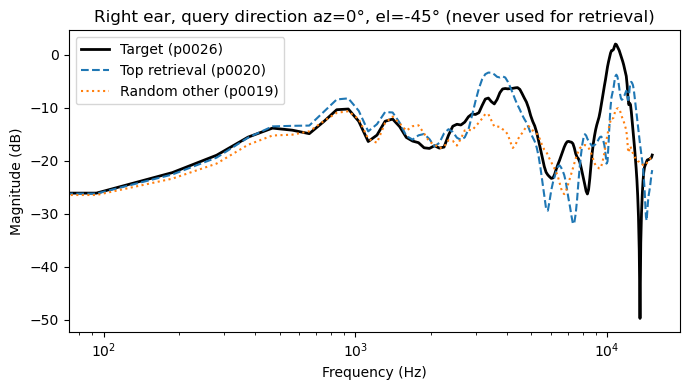

In [6]:
# Sanity check: does the top-retrieved subject actually look closer to the target than a random subject,
# on a QUERY direction it was never chosen from (retrieval only looked at the support directions)?
s_check = test_subject_idx[0]
best_retrieved = retrieved_subject_idx[int(s_check)][0]
random_other = train_subject_idx[-1] if train_subject_idx[-1] != best_retrieved else train_subject_idx[-2]

q = query_idx[0]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(freqs_hz, log_mag[s_check, q, 1], label=f"Target ({subject_ids[s_check]})", linewidth=2, color="black")
ax.plot(freqs_hz, log_mag[best_retrieved, q, 1], label=f"Top retrieval ({subject_ids[best_retrieved]})", linestyle="--")
ax.plot(freqs_hz, log_mag[random_other, q, 1], label=f"Random other ({subject_ids[random_other]})", linestyle=":")
ax.set_xscale("log"); ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
az_q, el_q, _ = positions[q]
ax.set_title(f"Right ear, query direction az={az_q:.0f}°, el={el_q:.0f}° (never used for retrieval)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. SIREN field with retrieval-augmented input

Both models use the same SIREN backbone, gradient-inferred latent code, and output representation. RANF incorporates an additional encoded retrieval input:

- **Baseline**: `field([direction, latent z])`
- **RANF**: `field([direction, latent z, encoded retrieval])`

The latent code is inferred in `infer_latent` where the field is conditioned on the HRTFs of the retrieved subjects at the support directions. Following notebook 01, the latent code is updated from the origin using a single gradient step. Then, the field receives those subjects' query-direction HRTFs together with the inferred `z` to predict the target subject's HRTF.

This differs from RANF in the original paper, which uses a richer BLSTM-based architecture and a separate adaptation procedure. The simplified design keeps the retrieval mechanism visible while remaining consistent with the neural-field workflow introduced in Notebook 01.

In [7]:
class SirenLayer(nn.Module):
    def __init__(self, in_f, out_f, w0=30.0, is_first=False, is_last=False):
        super().__init__()
        self.w0 = w0
        self.linear = nn.Linear(in_f, out_f)
        self.is_last = is_last
        b = 1 / in_f if is_first else np.sqrt(6 / in_f) / w0
        with torch.no_grad():
            self.linear.weight.uniform_(-b, b)

    def forward(self, x):
        x = self.linear(x)
        return x if self.is_last else torch.sin(self.w0 * x)


def build_siren(dims, w0):
    layers = [SirenLayer(dims[0], dims[1], w0=w0, is_first=True)]
    for d0, d1 in zip(dims[1:-2], dims[2:-1]):
        layers.append(SirenLayer(d0, d1, w0=w0))
    layers.append(SirenLayer(dims[-2], dims[-1], w0=w0, is_last=True))
    return nn.Sequential(*layers)


def retrieval_features(retrieved_idx, idx):
    """Mean (over K retrieved subjects) normalized log-magnitude at directions `idx`. [len(idx), 2*F]"""
    retrieved = log_mag_t[retrieved_idx][:, idx]
    return retrieved.mean(dim=0).reshape(len(idx), -1)


def build_ranf_components(use_retrieval):
    latent_dim = cfg["latent_dim"]
    retrieval_dim = cfg["retrieval_dim"] if use_retrieval else 0
    retrieval_encoder = None
    if use_retrieval:
        retrieval_encoder = nn.Sequential(
            nn.Linear(2 * cfg["n_freq_bins"], 64),nn.GELU(),
            nn.Linear(64, retrieval_dim),
        ).to(device)

    dims = ([2 + latent_dim + retrieval_dim]
            + [cfg["hidden_dim"] for _ in range(cfg["n_layers"] - 1)]
            + [2 * cfg["n_freq_bins"]])
    field = build_siren(dims, cfg["w0"]).to(device)

    def forward_field(dirs, z, retr_raw):
        parts = [dirs, z]
        if use_retrieval:
            parts.append(retrieval_encoder(retr_raw))
        return field(torch.cat(parts, dim=-1))

    def infer_latent(support_dirs, support_targets, support_retr):
        z0 = torch.zeros(1, latent_dim, device=device, requires_grad=True)
        z0_rep = z0.repeat(support_dirs.shape[0], 1)
        pred = forward_field(support_dirs, z0_rep, support_retr)
        loss = nn.functional.mse_loss(pred, support_targets)
        grad = torch.autograd.grad(loss, [z0], create_graph=True)[0]
        return -grad

    def subject_losses(s, targets, support_idx, query_idx):
        support_dirs, support_targets = dir_feats_t[support_idx], targets[support_idx]
        query_dirs, query_targets = dir_feats_t[query_idx], targets[query_idx]

        retrieved_idx = retrieved_subject_idx[int(s)] if use_retrieval else None
        support_retr = retrieval_features(retrieved_idx, support_idx) if use_retrieval else None
        query_retr = retrieval_features(retrieved_idx, query_idx) if use_retrieval else None
        z = infer_latent(support_dirs, support_targets, support_retr)

        z_rep = z.repeat(query_dirs.shape[0], 1)
        pred = forward_field(query_dirs, z_rep, query_retr)
        loss = nn.functional.mse_loss(pred, query_targets)
        return loss, pred, query_targets

    trainable = list(field.parameters()) + (list(retrieval_encoder.parameters()) if use_retrieval else [])
    modules = nn.ModuleList([field] + ([retrieval_encoder] if use_retrieval else []))
    return subject_losses, trainable, modules

## 5. Train both: baseline (no retrieval) vs. RANF (with retrieval)

Following the training loop in notebook 01, we assess the no-retrieval baseline and RANF with the same support→infer-z→predict-query mechanism.

Training (baseline, no retrieval): 100%|██████████| 300/300 [01:05<00:00,  4.56it/s, loss=0.121, val_loss=0.176]


[baseline, no retrieval] restored checkpoint from epoch 299 (best validation loss = 0.1676)


Training (RANF, K=2 retrieval): 100%|██████████| 300/300 [01:22<00:00,  3.64it/s, loss=0.115, val_loss=0.166]


[RANF, K=2 retrieval] restored checkpoint from epoch 200 (best validation loss = 0.1631)


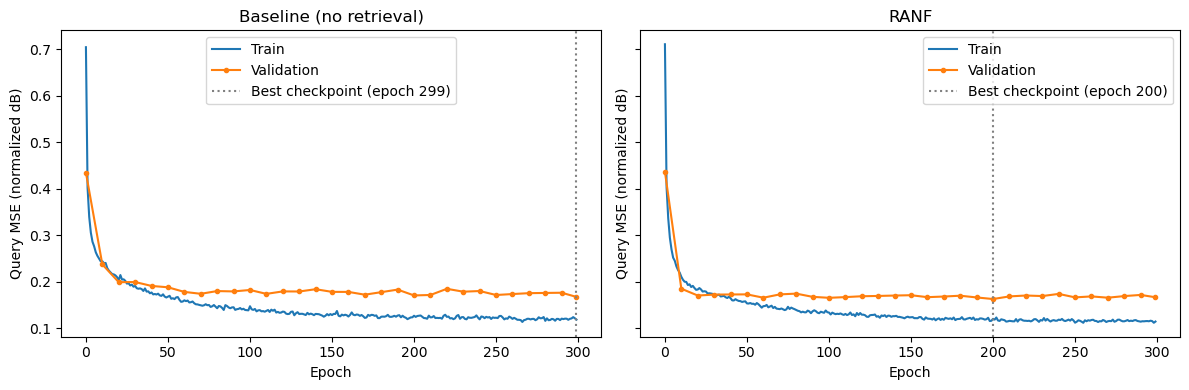

In [8]:
targets_flat = log_mag_t.reshape(n_subjects, n_dir, -1)

def train_field(use_retrieval, label):
    torch.manual_seed(0)
    np.random.seed(0)
    subject_losses, trainable, modules = build_ranf_components(use_retrieval)
    optimizer = torch.optim.Adam(trainable, lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    eval_every = max(1, cfg["n_epochs"] // 30)
    train_losses, val_losses, val_epochs = [], [], []
    best_val, best_epoch, best_state = float("inf"), None, None
    pbar = tqdm(range(cfg["n_epochs"]), desc=f"Training ({label})")
    for epoch in pbar:
        epoch_loss = 0.0
        for s in train_subject_idx:
            loss, _, _ = subject_losses(s, targets_flat[s], support_idx, query_idx)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_subject_idx)
        train_losses.append(epoch_loss)

        if epoch % eval_every == 0 or epoch == cfg["n_epochs"] - 1:
            val_loss = np.mean([
                subject_losses(s, targets_flat[s], support_idx, query_idx)[0].item()
                for s in val_subject_idx
            ])
            val_losses.append(val_loss)
            val_epochs.append(epoch)
            if val_loss < best_val:
                best_val, best_epoch = val_loss, epoch
                best_state = copy.deepcopy(modules.state_dict())

        if epoch % max(1, cfg["n_epochs"] // 10) == 0:
            pbar.set_postfix(loss=epoch_loss, val_loss=val_losses[-1])

    if best_state is None:
        raise RuntimeError(f"[{label}] no valid validation checkpoint was created.")
    modules.load_state_dict(best_state, strict=True)
    modules.eval()
    print(f"[{label}] restored checkpoint from epoch {best_epoch} (best validation loss = {best_val:.4f})")
    return dict(subject_losses=subject_losses, train_losses=train_losses,
                val_losses=val_losses, val_epochs=val_epochs, best_epoch=best_epoch)

results = {}
results["baseline"] = train_field(False, "baseline, no retrieval")
results["ranf"] = train_field(True, f"RANF, K={cfg['n_retrieved']} retrieval")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, key, title in zip(axes, ["baseline", "ranf"], ["Baseline (no retrieval)", "RANF"]):
    r = results[key]
    ax.plot(range(cfg["n_epochs"]), r["train_losses"], label="Train")
    ax.plot(r["val_epochs"], r["val_losses"], label="Validation", marker="o", markersize=3)
    ax.axvline(r["best_epoch"], color="gray", linestyle=":", label=f"Best checkpoint (epoch {r['best_epoch']})")
    ax.set_title(title)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Query MSE (normalized dB)")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate: train / validation / test LSD, baseline vs. RANF

In [9]:
def evaluate_subjects(subject_losses_fn, subject_idx_list, label):
    all_lsd = []
    for s in subject_idx_list:
        loss, pred, target = subject_losses_fn(s, targets_flat[s], support_idx, query_idx)
        pred_db = pred.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
        true_db = target.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
        lsd = np.sqrt(np.mean((pred_db - true_db) ** 2, axis=-1))
        all_lsd.append(lsd.mean())
    all_lsd = np.array(all_lsd)
    print(f"{label}: mean LSD = {all_lsd.mean():.2f} dB over {len(subject_idx_list)} subject(s)")
    return all_lsd

lsd_results = {}
for key, name in [("baseline", "Baseline"), ("ranf", "RANF")]:
    subject_losses_fn = results[key]["subject_losses"]
    lsd_results[key] = {
        "train": evaluate_subjects(subject_losses_fn, train_subject_idx, f"{name} — training subjects"),
        "val": evaluate_subjects(subject_losses_fn, val_subject_idx, f"{name} — validation subjects"),
        "test": evaluate_subjects(subject_losses_fn, test_subject_idx, f"{name} — test subjects"),
    }

Baseline — training subjects: mean LSD = 3.32 dB over 20 subject(s)
Baseline — validation subjects: mean LSD = 3.94 dB over 5 subject(s)
Baseline — test subjects: mean LSD = 4.43 dB over 5 subject(s)
RANF — training subjects: mean LSD = 3.20 dB over 20 subject(s)
RANF — validation subjects: mean LSD = 3.90 dB over 5 subject(s)
RANF — test subjects: mean LSD = 4.31 dB over 5 subject(s)


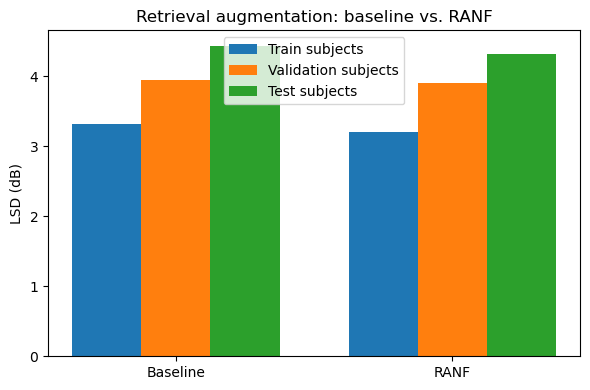

In [10]:
labels = ["Baseline", "RANF"]
keys = ["baseline", "ranf"]
train_means = [lsd_results[k]["train"].mean() for k in keys]
val_means = [lsd_results[k]["val"].mean() for k in keys]
test_means = [lsd_results[k]["test"].mean() for k in keys]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width, train_means, width, label="Train subjects")
ax.bar(x, val_means, width, label="Validation subjects")
ax.bar(x + width, test_means, width, label="Test subjects")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("LSD (dB)")
ax.set_title("Retrieval augmentation: baseline vs. RANF")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Qualitative check: what does the retrieved subject actually contribute?

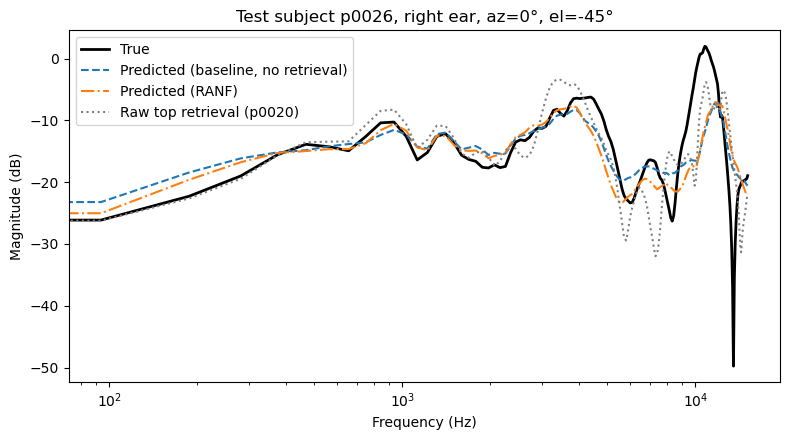

In [11]:
s_example = test_subject_idx[0]
_, pred_base, true_db_t = results["baseline"]["subject_losses"](s_example, targets_flat[s_example], support_idx, query_idx)
_, pred_ranf, _ = results["ranf"]["subject_losses"](s_example, targets_flat[s_example], support_idx, query_idx)

pred_base_db = pred_base.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
pred_ranf_db = pred_ranf.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean
true_db = true_db_t.detach().cpu().numpy().reshape(-1, 2, cfg["n_freq_bins"]) * mag_std + mag_mean

q = 0
az_q, el_q, _ = positions[query_idx[q]]
retrieved_top = retrieved_subject_idx[int(s_example)][0]
retrieved_db = log_mag[retrieved_top, query_idx[q], 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(freqs_hz, true_db[q, 1], color="black", linewidth=2, label="True")
ax.plot(freqs_hz, pred_base_db[q, 1], linestyle="--", label="Predicted (baseline, no retrieval)")
ax.plot(freqs_hz, pred_ranf_db[q, 1], linestyle="-.", label="Predicted (RANF)")
ax.plot(freqs_hz, retrieved_db, linestyle=":", color="gray", label=f"Raw top retrieval ({subject_ids[retrieved_top]})")
ax.set_xscale("log"); ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
ax.set_title(f"Test subject {subject_ids[s_example]}, right ear, az={az_q:.0f}°, el={el_q:.0f}°")
ax.legend()
plt.tight_layout()
plt.show()

## Recap

- RANF supplements a gradient-inferred latent code with direction-dependent HRTFs from $K$ similar training subjects.
- For each target subject, candidates from the training set are ranked by their HRTF similarity at the support directions.
- This tutorial uses magnitude-only LSD retrieval, mean aggregation, and a small encoder instead of the paper's BLSTM, learned aggregation, and LoRA components.
- The baseline/RANF comparison uses identical subject splits and optimization settings, highlighting the value of retrieved HRTF context.